<a href="https://colab.research.google.com/github/Madu39627/Projects/blob/main/historical_es_from_yahoo_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install yfinance pandas numpy scipy matplotlib

Downloaded observations: 5032

DESCRIPTIVE STATISTICS
Observations             5032.000000
Mean                        0.001107
Median                      0.001121
Standard_Deviation          0.020256
Minimum                    -0.197470
Maximum                     0.130194
Skewness                   -0.253137
Excess_Kurtosis             5.864122
Annualized_Mean             0.278988
Annualized_Volatility       0.321552

FULL-SAMPLE HISTORICAL RISK
VaR: 0.056128 (5.6128%)
ES:  0.075218 (7.5218%)
Tail observations: 51

BACKTEST RESULTS
Violations: 72
Violation ratio: 1.5056
Kupiec p-value: 0.001076
Independence p-value: 0.137847
Conditional coverage p-value: 0.001586

ES TAIL DIAGNOSTIC
Mean realized tail loss: 0.060382
Mean ES forecast: 0.055378
Mean ES error: 0.005004


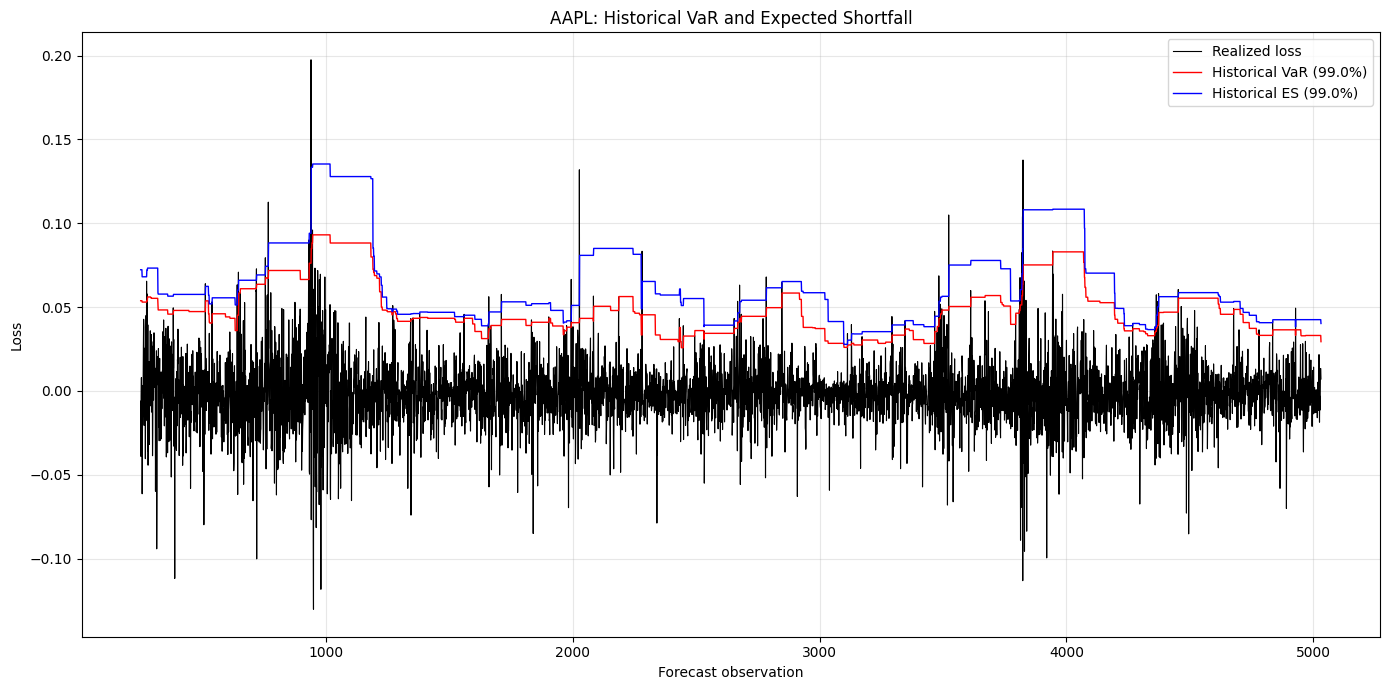


FILES CREATED
AAPL_historical_prices_returns.csv
output/AAPL_rolling_historical_es.csv
output/AAPL_historical_es_summary.csv
output/AAPL_historical_es_plot.png


In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import chi2


# ============================================================
# USER SETTINGS
# ============================================================

TICKER = "AAPL"              # Example: AAPL, MSFT, SPY, TSLA
START_DATE = "2005-01-01"
END_DATE = "2025-01-01"

CONFIDENCE_LEVEL = 0.99      # Use 0.95, 0.975, or 0.99
ESTIMATION_WINDOW = 250      # Number of historical trading days

PORTFOLIO_VALUE = None       # Example: 10_000_000


# ============================================================
# 1. DOWNLOAD HISTORICAL DATA
# ============================================================

def download_market_data(ticker, start_date, end_date):
    """
    Download adjusted historical prices from Yahoo Finance.
    """

    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False
    )

    if data.empty:
        raise ValueError(
            "No data was downloaded. Check the ticker and dates."
        )

    # Handle possible MultiIndex columns returned by yfinance
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.reset_index()

    if "Close" not in data.columns:
        raise ValueError(
            "The downloaded data does not contain a Close column."
        )

    data["Close"] = pd.to_numeric(
        data["Close"],
        errors="coerce"
    )

    data = data.dropna(subset=["Close"])

    return data


# ============================================================
# 2. CALCULATE LOG RETURNS
# ============================================================

def calculate_returns(data):
    """
    Calculate continuously compounded daily returns.
    """

    data = data.copy()

    data["Log_Return"] = np.log(
        data["Close"] / data["Close"].shift(1)
    )

    data = data.replace(
        [np.inf, -np.inf],
        np.nan
    )

    data = data.dropna(
        subset=["Log_Return"]
    ).reset_index(drop=True)

    return data


# ============================================================
# 3. DESCRIPTIVE STATISTICS
# ============================================================

def descriptive_statistics(returns):
    """
    Calculate descriptive statistics.
    """

    returns = pd.Series(returns).dropna()

    return pd.Series({
        "Observations": len(returns),
        "Mean": returns.mean(),
        "Median": returns.median(),
        "Standard_Deviation": returns.std(),
        "Minimum": returns.min(),
        "Maximum": returns.max(),
        "Skewness": returns.skew(),
        "Excess_Kurtosis": returns.kurtosis(),
        "Annualized_Mean": returns.mean() * 252,
        "Annualized_Volatility": returns.std() * np.sqrt(252),
    })


# ============================================================
# 4. HISTORICAL VaR AND ES
# ============================================================

def historical_var_es(
    losses,
    confidence_level=0.99
):
    """
    Calculate historical VaR and Expected Shortfall.

    Losses must be positive when the return is negative.
    """

    losses = pd.Series(losses).dropna().astype(float)

    if losses.empty:
        raise ValueError("The loss series is empty.")

    var_value = losses.quantile(
        confidence_level
    )

    tail_losses = losses[
        losses >= var_value
    ]

    es_value = tail_losses.mean()

    return {
        "VaR": float(var_value),
        "ES": float(es_value),
        "Tail_Observations": int(len(tail_losses)),
        "Tail_Rate": float(
            len(tail_losses) / len(losses)
        ),
    }


# ============================================================
# 5. ROLLING HISTORICAL VaR AND ES
# ============================================================

def rolling_historical_forecasts(
    returns,
    estimation_window=250,
    confidence_level=0.99
):
    """
    Generate one-day-ahead rolling historical VaR and ES.

    Only past observations are used for each forecast.
    This avoids look-ahead bias.
    """

    returns = (
        pd.Series(returns)
        .dropna()
        .reset_index(drop=True)
        .astype(float)
    )

    if len(returns) <= estimation_window:
        raise ValueError(
            "The sample is shorter than the estimation window."
        )

    results = []

    for forecast_index in range(
        estimation_window,
        len(returns)
    ):

        estimation_returns = returns.iloc[
            forecast_index - estimation_window:
            forecast_index
        ]

        estimation_losses = -estimation_returns

        risk = historical_var_es(
            losses=estimation_losses,
            confidence_level=confidence_level
        )

        realized_return = returns.iloc[
            forecast_index
        ]

        realized_loss = -realized_return

        results.append({
            "Forecast_Index": forecast_index,
            "Realized_Return": realized_return,
            "Realized_Loss": realized_loss,
            "VaR": risk["VaR"],
            "ES": risk["ES"],
            "VaR_Violation": int(
                realized_loss > risk["VaR"]
            ),
            "Tail_Observations": risk[
                "Tail_Observations"
            ],
        })

    return pd.DataFrame(results)


# ============================================================
# 6. KUPIEC TEST
# ============================================================

def kupiec_test(
    realized_losses,
    var_forecasts,
    confidence_level=0.99
):
    """
    Kupiec proportion-of-failures test.
    """

    losses = np.asarray(
        realized_losses,
        dtype=float
    )

    forecasts = np.asarray(
        var_forecasts,
        dtype=float
    )

    valid = (
        np.isfinite(losses)
        & np.isfinite(forecasts)
    )

    losses = losses[valid]
    forecasts = forecasts[valid]

    violations = losses > forecasts

    n = len(violations)
    x = int(violations.sum())

    if n == 0:
        raise ValueError(
            "No valid observations for Kupiec test."
        )

    expected_probability = 1 - confidence_level
    observed_probability = x / n

    def log_term(count, probability):
        if count == 0:
            return 0.0

        if probability <= 0:
            return -np.inf

        return count * np.log(probability)

    unrestricted_log_likelihood = (
        log_term(x, observed_probability)
        + log_term(
            n - x,
            1 - observed_probability
        )
    )

    restricted_log_likelihood = (
        log_term(x, expected_probability)
        + log_term(
            n - x,
            1 - expected_probability
        )
    )

    likelihood_ratio = -2 * (
        restricted_log_likelihood
        - unrestricted_log_likelihood
    )

    p_value = 1 - chi2.cdf(
        likelihood_ratio,
        df=1
    )

    return {
        "Observations": n,
        "Violations": x,
        "Expected_Violation_Rate": expected_probability,
        "Observed_Violation_Rate": observed_probability,
        "Violation_Ratio": (
            observed_probability
            / expected_probability
        ),
        "Kupiec_LR": likelihood_ratio,
        "Kupiec_P_Value": p_value,
    }


# ============================================================
# 7. CHRISTOFFERSEN INDEPENDENCE TEST
# ============================================================

def christoffersen_independence_test(
    realized_losses,
    var_forecasts
):
    """
    Christoffersen first-order independence test.
    """

    losses = np.asarray(
        realized_losses,
        dtype=float
    )

    forecasts = np.asarray(
        var_forecasts,
        dtype=float
    )

    valid = (
        np.isfinite(losses)
        & np.isfinite(forecasts)
    )

    violations = (
        losses[valid] > forecasts[valid]
    ).astype(int)

    if len(violations) < 2:
        raise ValueError(
            "At least two observations are required."
        )

    n00 = 0
    n01 = 0
    n10 = 0
    n11 = 0

    for previous, current in zip(
        violations[:-1],
        violations[1:]
    ):
        if previous == 0 and current == 0:
            n00 += 1
        elif previous == 0 and current == 1:
            n01 += 1
        elif previous == 1 and current == 0:
            n10 += 1
        else:
            n11 += 1

    n0 = n00 + n01
    n1 = n10 + n11
    total = n00 + n01 + n10 + n11

    total_violations = n01 + n11

    pi01 = n01 / n0 if n0 > 0 else 0
    pi11 = n11 / n1 if n1 > 0 else 0
    pi = (
        total_violations / total
        if total > 0
        else 0
    )

    def log_term(count, probability):
        if count == 0:
            return 0.0

        if probability <= 0:
            return -np.inf

        return count * np.log(probability)

    unrestricted_log_likelihood = (
        log_term(n00, 1 - pi01)
        + log_term(n01, pi01)
        + log_term(n10, 1 - pi11)
        + log_term(n11, pi11)
    )

    restricted_log_likelihood = (
        log_term(n00 + n10, 1 - pi)
        + log_term(n01 + n11, pi)
    )

    likelihood_ratio = -2 * (
        restricted_log_likelihood
        - unrestricted_log_likelihood
    )

    p_value = 1 - chi2.cdf(
        likelihood_ratio,
        df=1
    )

    return {
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11,
        "Independence_LR": likelihood_ratio,
        "Independence_P_Value": p_value,
    }


# ============================================================
# 8. CONDITIONAL COVERAGE TEST
# ============================================================

def conditional_coverage_test(
    realized_losses,
    var_forecasts,
    confidence_level=0.99
):
    """
    Combine Kupiec coverage and Christoffersen
    independence tests.
    """

    kupiec = kupiec_test(
        realized_losses,
        var_forecasts,
        confidence_level
    )

    independence = (
        christoffersen_independence_test(
            realized_losses,
            var_forecasts
        )
    )

    conditional_coverage_lr = (
        kupiec["Kupiec_LR"]
        + independence["Independence_LR"]
    )

    p_value = 1 - chi2.cdf(
        conditional_coverage_lr,
        df=2
    )

    return {
        "Conditional_Coverage_LR":
            conditional_coverage_lr,
        "Conditional_Coverage_P_Value":
            p_value,
        "Kupiec_P_Value":
            kupiec["Kupiec_P_Value"],
        "Independence_P_Value":
            independence[
                "Independence_P_Value"
            ],
        "Violations":
            kupiec["Violations"],
        "Violation_Ratio":
            kupiec["Violation_Ratio"],
    }


# ============================================================
# 9. ES TAIL-LOSS DIAGNOSTIC
# ============================================================

def es_tail_diagnostic(
    realized_losses,
    var_forecasts,
    es_forecasts
):
    """
    Compare realized losses with ES on VaR violation days.

    This is a descriptive diagnostic and not a complete
    formal ES backtest.
    """

    losses = np.asarray(
        realized_losses,
        dtype=float
    )

    var_values = np.asarray(
        var_forecasts,
        dtype=float
    )

    es_values = np.asarray(
        es_forecasts,
        dtype=float
    )

    valid = (
        np.isfinite(losses)
        & np.isfinite(var_values)
        & np.isfinite(es_values)
    )

    losses = losses[valid]
    var_values = var_values[valid]
    es_values = es_values[valid]

    violations = losses > var_values

    tail_losses = losses[violations]
    tail_es = es_values[violations]

    if len(tail_losses) == 0:
        return {
            "VaR_Violations": 0,
            "Mean_Realized_Tail_Loss": np.nan,
            "Mean_ES_Forecast": np.nan,
            "Mean_ES_Error": np.nan,
            "ES_Conservative_Rate": np.nan,
        }

    return {
        "VaR_Violations": len(tail_losses),
        "Mean_Realized_Tail_Loss":
            tail_losses.mean(),
        "Mean_ES_Forecast":
            tail_es.mean(),
        "Mean_ES_Error":
            (tail_losses - tail_es).mean(),
        "ES_Conservative_Rate":
            np.mean(tail_losses <= tail_es),
    }


# ============================================================
# 10. MAIN ANALYSIS
# ============================================================

def main():
    print(f"Downloading data for {TICKER}...")

    data = download_market_data(
        ticker=TICKER,
        start_date=START_DATE,
        end_date=END_DATE
    )

    data = calculate_returns(data)

    returns = data["Log_Return"]
    losses = -returns

    print(f"Downloaded observations: {len(data)}")

    # Save downloaded prices and returns
    data.to_csv(
        f"{TICKER}_historical_prices_returns.csv",
        index=False
    )

    # Descriptive statistics
    print("\nDESCRIPTIVE STATISTICS")
    print(
        descriptive_statistics(
            returns
        ).to_string()
    )

    # Full-sample historical VaR and ES
    full_sample = historical_var_es(
        losses=losses,
        confidence_level=CONFIDENCE_LEVEL
    )

    print("\nFULL-SAMPLE HISTORICAL RISK")
    print(
        f"VaR: {full_sample['VaR']:.6f} "
        f"({full_sample['VaR']:.4%})"
    )

    print(
        f"ES:  {full_sample['ES']:.6f} "
        f"({full_sample['ES']:.4%})"
    )

    print(
        f"Tail observations: "
        f"{full_sample['Tail_Observations']}"
    )

    # Convert risk estimates to monetary terms
    if PORTFOLIO_VALUE is not None:
        print("\nMONETARY RISK")
        print(
            "VaR monetary loss:",
            full_sample["VaR"] * PORTFOLIO_VALUE
        )
        print(
            "ES monetary loss:",
            full_sample["ES"] * PORTFOLIO_VALUE
        )

    # Rolling forecasts
    rolling_results = rolling_historical_forecasts(
        returns=returns,
        estimation_window=ESTIMATION_WINDOW,
        confidence_level=CONFIDENCE_LEVEL
    )

    # Backtests
    kupiec_results = kupiec_test(
        realized_losses=rolling_results[
            "Realized_Loss"
        ],
        var_forecasts=rolling_results[
            "VaR"
        ],
        confidence_level=CONFIDENCE_LEVEL
    )

    independence_results = (
        christoffersen_independence_test(
            realized_losses=rolling_results[
                "Realized_Loss"
            ],
            var_forecasts=rolling_results[
                "VaR"
            ]
        )
    )

    conditional_results = (
        conditional_coverage_test(
            realized_losses=rolling_results[
                "Realized_Loss"
            ],
            var_forecasts=rolling_results[
                "VaR"
            ],
            confidence_level=CONFIDENCE_LEVEL
        )
    )

    es_results = es_tail_diagnostic(
        realized_losses=rolling_results[
            "Realized_Loss"
        ],
        var_forecasts=rolling_results[
            "VaR"
        ],
        es_forecasts=rolling_results[
            "ES"
        ]
    )

    print("\nBACKTEST RESULTS")
    print(
        f"Violations: "
        f"{kupiec_results['Violations']}"
    )

    print(
        f"Violation ratio: "
        f"{kupiec_results['Violation_Ratio']:.4f}"
    )

    print(
        f"Kupiec p-value: "
        f"{kupiec_results['Kupiec_P_Value']:.6f}"
    )

    print(
        f"Independence p-value: "
        f"{independence_results['Independence_P_Value']:.6f}"
    )

    print(
        f"Conditional coverage p-value: "
        f"{conditional_results['Conditional_Coverage_P_Value']:.6f}"
    )

    print("\nES TAIL DIAGNOSTIC")
    print(
        f"Mean realized tail loss: "
        f"{es_results['Mean_Realized_Tail_Loss']:.6f}"
    )

    print(
        f"Mean ES forecast: "
        f"{es_results['Mean_ES_Forecast']:.6f}"
    )

    print(
        f"Mean ES error: "
        f"{es_results['Mean_ES_Error']:.6f}"
    )

    # Create output folder
    output_folder = Path("output")
    output_folder.mkdir(exist_ok=True)

    # Save rolling results
    rolling_results.to_csv(
        output_folder
        / f"{TICKER}_rolling_historical_es.csv",
        index=False
    )

    # Save summary
    summary = pd.DataFrame({
        "Metric": [
            "Full-sample VaR",
            "Full-sample ES",
            "Full-sample tail observations",
            "Rolling observations",
            "VaR violations",
            "Observed violation rate",
            "Violation ratio",
            "Kupiec p-value",
            "Independence p-value",
            "Conditional coverage p-value",
            "Mean realized tail loss",
            "Mean ES forecast",
            "Mean ES error",
            "ES conservative rate",
        ],
        "Value": [
            full_sample["VaR"],
            full_sample["ES"],
            full_sample["Tail_Observations"],
            len(rolling_results),
            kupiec_results["Violations"],
            kupiec_results[
                "Observed_Violation_Rate"
            ],
            kupiec_results[
                "Violation_Ratio"
            ],
            kupiec_results[
                "Kupiec_P_Value"
            ],
            independence_results[
                "Independence_P_Value"
            ],
            conditional_results[
                "Conditional_Coverage_P_Value"
            ],
            es_results[
                "Mean_Realized_Tail_Loss"
            ],
            es_results[
                "Mean_ES_Forecast"
            ],
            es_results[
                "Mean_ES_Error"
            ],
            es_results[
                "ES_Conservative_Rate"
            ],
        ]
    })

    if PORTFOLIO_VALUE is not None:
        monetary_rows = pd.DataFrame({
            "Metric": [
                "VaR monetary loss",
                "ES monetary loss",
            ],
            "Value": [
                full_sample["VaR"]
                * PORTFOLIO_VALUE,
                full_sample["ES"]
                * PORTFOLIO_VALUE,
            ]
        })

        summary = pd.concat(
            [summary, monetary_rows],
            ignore_index=True
        )

    summary.to_csv(
        output_folder
        / f"{TICKER}_historical_es_summary.csv",
        index=False
    )

    # Plot results
    plt.figure(figsize=(14, 7))

    plt.plot(
        rolling_results["Forecast_Index"],
        rolling_results["Realized_Loss"],
        color="black",
        linewidth=0.8,
        label="Realized loss"
    )

    plt.plot(
        rolling_results["Forecast_Index"],
        rolling_results["VaR"],
        color="red",
        linewidth=1,
        label=f"Historical VaR "
              f"({CONFIDENCE_LEVEL:.1%})"
    )

    plt.plot(
        rolling_results["Forecast_Index"],
        rolling_results["ES"],
        color="blue",
        linewidth=1,
        label=f"Historical ES "
              f"({CONFIDENCE_LEVEL:.1%})"
    )

    plt.title(
        f"{TICKER}: Historical VaR and Expected Shortfall"
    )

    plt.xlabel("Forecast observation")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        output_folder
        / f"{TICKER}_historical_es_plot.png",
        dpi=300
    )

    plt.show()

    print("\nFILES CREATED")
    print(f"{TICKER}_historical_prices_returns.csv")
    print(
        output_folder
        / f"{TICKER}_rolling_historical_es.csv"
    )
    print(
        output_folder
        / f"{TICKER}_historical_es_summary.csv"
    )
    print(
        output_folder
        / f"{TICKER}_historical_es_plot.png"
    )


if __name__ == "__main__":
    main()